In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

from torchvision import transforms

In [51]:
Batch_size = 32
Img_size = 224
Epochs = 30
Learning_rate = 1e-4
Weight_decay = 1e-5
Checkout_path = '/kaggle/working/best_fairface_model.pth'

In [52]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd

dataset = load_dataset("HuggingFaceM4/FairFace", "0.25")
full_train_ds = dataset["train"]
test_data = dataset["validation"]

# Change target labels to a pandas structure for balanced sampling
df = full_train_ds.remove_columns("image").to_pandas()

# Stratified sampling is applied using the age category as the main target
df["strata"] = df["age"].astype(str)

# Select 35,000 stratified samples
_, subset_df = train_test_split(
    df,
    test_size=35000,
    stratify=df["strata"],
    random_state=42
)
selected_indices = subset_df.index.tolist()
train_ds = full_train_ds.select(selected_indices)

# create validation set
train_valid = train_ds.train_test_split(
    test_size=0.15,
    seed=42,
    stratify_by_column="age"
)

train_data = train_valid["train"]
val_data = train_valid["test"]

print(train_data)
print(val_data)
print(test_data)

Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 29750
})
Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 5250
})
Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 10954
})


## Section 1 – Dataset Exploration and Visualization

In [53]:
# Number of samples
train_data = train_valid["train"]
val_data = train_valid["test"]
test_data = test_data

print(train_data)
print(val_data)
print(test_data)
print(f"\n\ntraining samples: {len(train_data)}")
print(f"validation samples: {len(val_data)}")
print(f"test samples: {len(test_data)}")

Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 29750
})
Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 5250
})
Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 10954
})


training samples: 29750
validation samples: 5250
test samples: 10954


In [54]:
age_names = train_data.features["age"].names
gender_names = train_data.features["gender"].names
race_names = train_data.features["race"].names
print(age_names)
print(gender_names)
print(race_names)

['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']
['Male', 'Female']
['East Asian', 'Indian', 'Black', 'White', 'Middle Eastern', 'Latino_Hispanic', 'Southeast Asian']


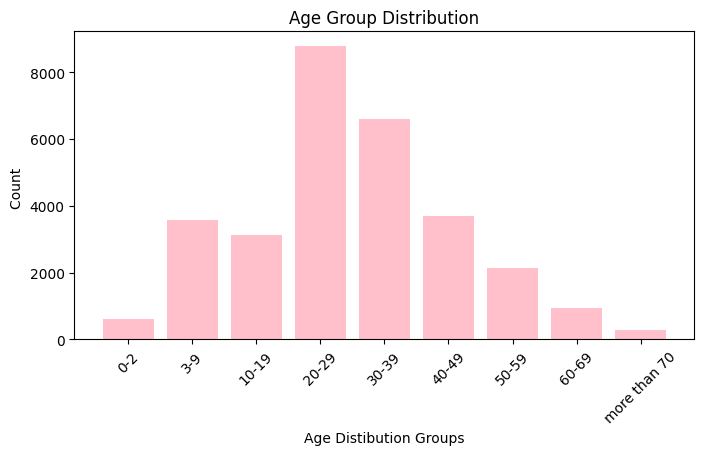

In [55]:
# Class distribution for age groups 
from collections import Counter

ages = [age_names[x["age"]] for x in train_data]
age_counts = Counter(ages)
age_values = [age_counts[age] for age in age_names]

plt.figure(figsize=(8,4))
plt.bar(age_names, age_values,color="pink")
plt.xticks(rotation=45)
plt.title("Age Group Distribution")
plt.xlabel("Age Distibution Groups")
plt.ylabel("Count ")
plt.show()

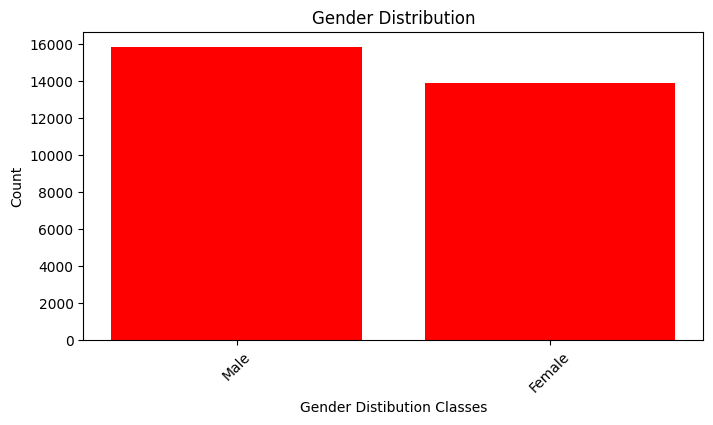

In [56]:
# The Gender distribution 
genders = [gender_names[x["gender"]] for x in train_data]
gender_counts = Counter(genders)
gender_values = [gender_counts[gender] for gender in gender_names]

plt.figure(figsize=(8,4))
plt.bar(gender_names, gender_values,color="red")
plt.xticks(rotation=45)
plt.title("Gender Distribution")
plt.xlabel("Gender Distibution Classes")
plt.ylabel("Count")
plt.show()

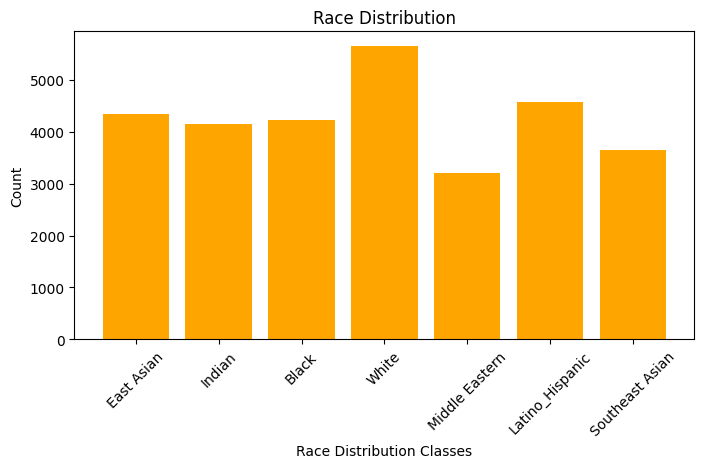

In [57]:
# Race distribution 
races = [race_names[x["race"]] for x in train_data]
race_counts = Counter(races)
race_values = [race_counts[race] for race in race_names]

plt.figure(figsize=(8,4))
plt.bar(race_names, race_values,color="orange")
plt.xticks(rotation=45)
plt.title("Race Distribution")
plt.xlabel("Race Distribution Classes")
plt.ylabel("Count")
plt.show()

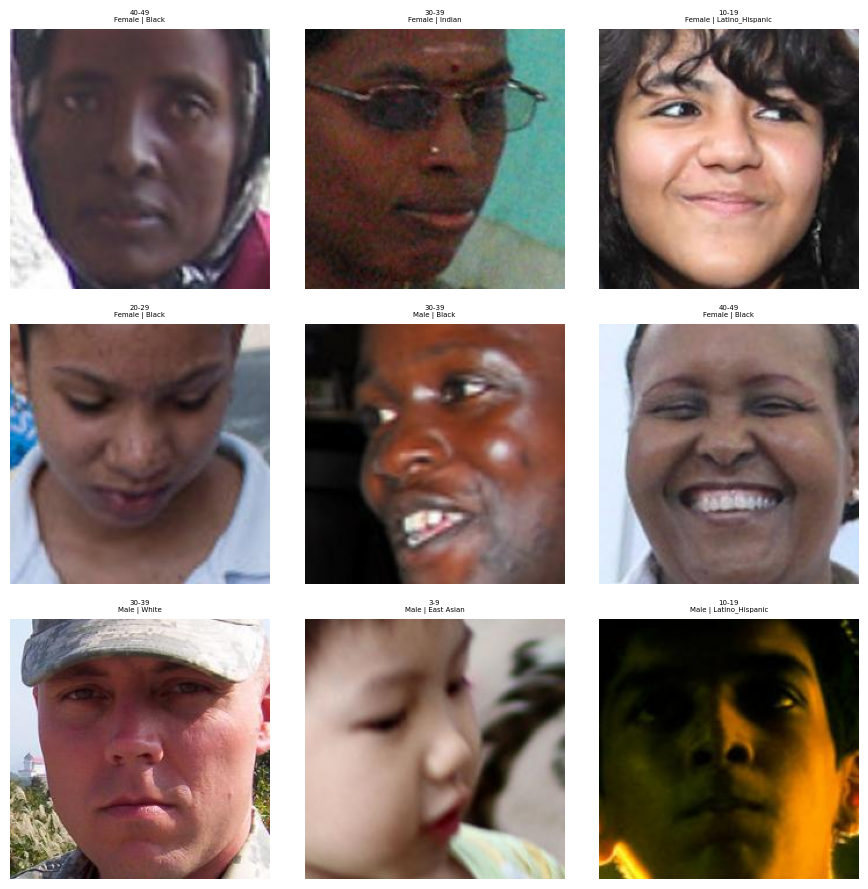

In [58]:
# Examples of image variation
plt.figure(figsize=(9, 9))

for i in range(9):
    img = train_data[i]["image"]
    age = age_names[train_data[i]["age"]]
    gender = gender_names[train_data[i]["gender"]]
    race = race_names[train_data[i]["race"]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{age}\n{gender} | {race}", fontsize=5)
    plt.axis("off")

plt.tight_layout()
plt.show()

## A short discussion of dataset strengths and limitations.

This project aims to create an effective CNN model for age-based classification of images from the FairFace dataset, where predictions would refer to one of the nine age categories, as well as provide information about the fairness of results across different gender and race categories.

The total number of images in the FairFace dataset equals 97,698 and includes three subsets – training, validation, and testing, each containing 29,750, 5,250, and 10,954 photos, respectively. All images are annotated for age, gender, and race information.

Preliminary data analysis suggests some uneven distribution in terms of age categories, as most images refer to individuals aged 20-39, while images in other age categories are somewhat limited. In turn, gender distribution appears to be relatively even despite differences in the representation of different races.

As for images in the dataset, there is notable diversity with regard to such elements as illumination, expression, head pose, and background. Therefore, the current dataset is valuable for development of real-world applications, including classification tasks.

Finally, it should be noted that the provided images do not include any missing annotations, but possible label inconsistencies need to be accounted for as well. All things considered, FairFace dataset is suitable for solving

### Section 2 - Data Preparation

In [59]:
# The official Hugging Face train split was used to create the training and internal validation sets
# The official Hugging Face validation split was kept as the final held-out test set

    
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((Img_size, Img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
val_transform = transforms.Compose([
    transforms.Resize((Img_size, Img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [60]:
# Apply image preprocessing and label mapping to the training, validation, and test datasets using transformation functions

def train_transform_fn(batch):
    images = [train_transform(img) for img in batch["image"]]
    labels = batch["age"]

    return {
        "image": images,
        "label": labels
    }
def val_transform_fn(batch):
    images = [val_transform(img) for img in batch["image"]]
    labels = batch["age"]

    return {
        "image": images,
        "label": labels
    }
train_data = train_data.with_transform(train_transform_fn)
val_data = val_data.with_transform(val_transform_fn)
test_data = test_data.with_transform(val_transform_fn)

In [61]:
# Create custom DataLoaders for training, validation, and testing 
# by batching images and labels using a collate function
# Then display the number of batches and sample a batch for verification.
def collate_fn(batch):
    images = torch.stack([x["image"] for x in batch])
    labels = torch.tensor([x["label"] for x in batch])
    return images, labels
train_loader = DataLoader(
    train_data,
    batch_size=Batch_size,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_data,
    batch_size=Batch_size,
    shuffle=False,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    test_data,
    batch_size=Batch_size,
    shuffle=False,
    collate_fn=collate_fn
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")
images, labels = next(iter(train_loader))




Number of training batches: 930
Number of validation batches: 165
Number of test batches: 343


### Section 3 - Baseline CNN Model

In [62]:
# Define an improved CNN architecture
import torch.nn as nn

class BetterCNN(nn.Module):

    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
 

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BetterCNN(num_classes=9)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


Using 2 GPUs


### Section 4 - Performance Evaluation

In [64]:
# List for monitoring training and validation loss
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

def evaluate(model, data_loader):
    model.eval()  
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): 
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images) 
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)  

            predicted = outputs.argmax(dim=1)  # Get the predicted class with the highest score
            total += labels.size(0)  # Update total number of samples
            correct += (predicted == labels).sum().item()  # Update number of correct predictions

    epoch_avg_loss = running_loss / len(data_loader.dataset) 
    epoch_accuracy = 100 * (correct / total) 
    return epoch_avg_loss, epoch_accuracy

In [ ]:
for epochs in range(Epochs):
    model.train()
    running_epochs_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        
        running_epochs_train_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = running_epochs_train_loss / len(train_loader.dataset)
    epoch_train_accuracy = 100 * (train_correct / train_total)

    epoch_val_loss, epoch_val_accuracy = evaluate(model, val_loader)
    scheduler.step(epoch_val_accuracy)

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(
        f"Epoch [{epochs+1}/{Epochs}] - "
        f"Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.2f}% - "
        f"Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_val_accuracy:.2f}%"
        f" - Best Val Accuracy: {best_val_accuracy:.2f}%"
    )

    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(
            {
                "epoch": epochs + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy":epoch_val_accuracy,
                "val_loss": epoch_val_loss
            },
            Checkout_path,
        )
        print(f"New best model saved with validation accuracy: {best_val_accuracy:.2f}%")
        print(f"Best model saved at epoch {epochs+1})")

In [ ]:
import os

print(os.listdir("/kaggle/working"))

In [ ]:
import glob

print(glob.glob("/kaggle/working/*.pth"))
print(glob.glob("/kaggle/working/*.pt"))

In [ ]:
checkpoint_path = "/kaggle/working/best_model.pth"

In [ ]:
checkout_path = '/kaggle/working/best_fairface_model.pth'
checkpoint = torch.load(checkout_path, map_location=device)

print(checkpoint.keys())

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])

In [ ]:
test_loss, test_accuracy = evaluate(model, test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(classification_report(
    all_labels,
    all_preds,
    target_names=age_names
))

confusion_m = confusion_matrix(all_labels, all_preds)

print(confusion_m)

In [ ]:
raw_test_meta = dataset["validation"]
print(raw_test_meta[0])

In [ ]:
import pandas as pd

model.eval()

all_preds = []
all_labels = []
all_gender = []
all_race = []
sample_index = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        batch_size = labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        for j in range(batch_size):
            all_gender.append(raw_test_meta[sample_index]["gender"])
            all_race.append(raw_test_meta[sample_index]["race"])

            sample_index += 1

fairness_df = pd.DataFrame({
    "true_age": all_labels,
    "pred_age": all_preds,
    "gender": all_gender,
    "race": all_race
})
fairness_df["correct"] = (
    fairness_df["true_age"] == fairness_df["pred_age"]
)
fairness_df.head()

### Section 5 - Bias Detection and Fairness Audit

In [ ]:
# Group-wise accuracy/error rate across gender groups
gender_fairness = fairness_df.groupby("gender")["correct"].agg(["count", "mean"])
gender_fairness["accuracy_%"] = gender_fairness["mean"]*100
gender_fairness.index = [gender_names[i] for i in gender_fairness.index]
print(gender_fairness)

In [ ]:
# Group-wise accuracy/error rate across race groups
race_fairness = fairness_df.groupby("race")["correct"].agg(["count", "mean"])
race_fairness["accuracy_%"] = race_fairness["mean"]*100
race_fairness.index = [race_names[i] for i in race_fairness.index]
print(race_fairness)

In [ ]:
# Compare model accuracy percentages across different gender groups for fairness evaluation
import matplotlib.pyplot as plt

gender_fairness["accuracy_%"].plot(
    kind="bar",
    figsize=(8,4)
)
plt.ylabel("Accuracy (%)")
plt.title("Gender Fairness Evaluation")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Compare model accuracy percentages across different race groups for fairness analysis
race_fairness["accuracy_%"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Accuracy (%)")
plt.title("Race Fairness Evaluation")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Plot training and validation accuracy curves across epochs, 
# To monitor model learning performance and detect overfitting or underfitting.
epoch_numbers = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    epoch_numbers,
    train_accuracies,
    linewidth=4,
    label="Training Accuracy"
)

plt.plot(
    epoch_numbers,
    val_accuracies,
    linewidth=4,
    label="Validation Accuracy"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Training vs Validation Accuracy", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Plot training and validation Losses curves across epochs, 
# To monitor model learning performance and detect overfitting or underfitting.
epoch_numbers = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 4))

plt.plot(
    epoch_numbers,
    train_losses,
    linewidth=4,
    label="Training Loss"
)

plt.plot(
    epoch_numbers,
    val_losses,
    linewidth=4,
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a summary table includig key evaluation metrics  
summary_metrics = {
    "Best Validation Accuracy": 51.66,
    "Test Accuracy": 50.64,
    "Macro F1": 0.42,
    "Weighted F1": 0.49,
    "Gender Gap": 1.69,
    "Race Gap": 7.29
}
pd.DataFrame(summary_metrics.items(), columns=["Metric", "Value"])

### Section 6 - Bias mitigation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import numpy as np
import pandas as pd
import torch

def create_model():
    model = BetterCNN(num_classes=9)

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    return model.to(device)


def evaluate_with_criterion(model, data_loader, criterion_used):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion_used(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    return running_loss / len(data_loader.dataset), 100 * correct / total


def train_mitigation_model(model, train_loader_used, val_loader_used, criterion_used, epochs=10):

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=Learning_rate,
        weight_decay=Weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_acc = 0
    best_state = None

    for epoch in range(epochs):

        model.train()

        train_correct = 0
        train_total = 0

        for images, labels in train_loader_used:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion_used(outputs, labels)

            loss.backward()

            optimizer.step()

            preds = outputs.argmax(dim=1)

            train_correct += (preds == labels).sum().item()

            train_total += labels.size(0)

        train_acc = 100 * train_correct / train_total

        val_loss, val_acc = evaluate_with_criterion(
            model,
            val_loader_used,
            criterion_used
        )

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Accuracy: {train_acc:.2f}% | "
            f"Validation Accuracy: {val_acc:.2f}% | "
            f"Best Validation Accuracy: {best_val_acc:.2f}%"
        )

    model.load_state_dict(best_state)

    return model, best_val_acc

In [ ]:
# Functions for generating predictions,
# calculating fairness metrics,
# and evaluating mitigation models.

def get_predictions(model, loader):

    model.eval()

    preds_list = []
    labels_list = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            preds_list.extend(preds.cpu().numpy())

            labels_list.extend(labels.numpy())

    return np.array(labels_list), np.array(preds_list)


def fairness_metrics_from_predictions(labels, preds):

    raw_test_meta = dataset["validation"]

    genders = [raw_test_meta[i]["gender"] for i in range(len(labels))]

    races = [raw_test_meta[i]["race"] for i in range(len(labels))]

    df = pd.DataFrame({
        "true_age": labels,
        "pred_age": preds,
        "gender": genders,
        "race": races
    })

    df["correct"] = df["true_age"] == df["pred_age"]

    gender_result = df.groupby("gender")["correct"].mean() * 100

    race_result = df.groupby("race")["correct"].mean() * 100

    gender_gap = gender_result.max() - gender_result.min()

    race_gap = race_result.max() - race_result.min()

    return gender_gap, race_gap, gender_result, race_result


def evaluate_full_model(model, loader, best_val_acc, experiment_name):

    labels, preds = get_predictions(model, loader)

    test_acc = accuracy_score(labels, preds) * 100

    macro_f1 = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    gender_gap, race_gap, gender_result, race_result = fairness_metrics_from_predictions(
        labels,
        preds
    )

    result = {
        "Experiment": experiment_name,
        "Best Val Accuracy (%)": best_val_acc,
        "Test Accuracy (%)": test_acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Gender Gap (%)": gender_gap,
        "Race Gap (%)": race_gap
    }

    print(
        classification_report(
            labels,
            preds,
            target_names=age_names,
            zero_division=0
        )
    )

    return result, gender_result, race_result

### Mitigation Strategy 1 — Class Weighted Loss

In [ ]:

# Class-weighted loss was used to reduce imbalance between age groups by 
# assigning larger penalties to minority classes during training.
raw_train_data = train_valid["train"]

age_labels_train = [
    raw_train_data[i]["age"]
    for i in range(len(raw_train_data))
]

age_counts = Counter(age_labels_train)

num_classes = 9

total_samples = len(age_labels_train)

class_weights = torch.tensor([
    total_samples / (num_classes * age_counts[i])
    for i in range(num_classes)
], dtype=torch.float).to(device)

print("Class Weights:", class_weights)

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

model_weighted_loss = create_model()

model_weighted_loss, weighted_best_val_acc = train_mitigation_model(
    model=model_weighted_loss,
    train_loader_used=train_loader,
    val_loader_used=val_loader,
    criterion_used=weighted_criterion,
    epochs=25
)

weighted_result, weighted_gender_result, weighted_race_result = evaluate_full_model(
    model_weighted_loss,
    test_loader,
    weighted_best_val_acc,
    "Mitigation 1 - Class Weighted Loss"
)

### Mitigation Strategy 2 — Balanced Mini-Batch Sampling

In [ ]:

# Balanced mini-batch sampling was used to improve representation of minority classes during training using WeightedRandomSampler.

sample_weights = [
    1.0 / age_counts[label]
    for label in age_labels_train
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

balanced_train_loader = DataLoader(
    train_data,
    batch_size=Batch_size,
    sampler=sampler,
    collate_fn=collate_fn
)

balanced_criterion = nn.CrossEntropyLoss()

model_balanced_sampler = create_model()

model_balanced_sampler, balanced_best_val_acc = train_mitigation_model(
    model=model_balanced_sampler,
    train_loader_used=balanced_train_loader,
    val_loader_used=val_loader,
    criterion_used=balanced_criterion,
    epochs=25
)

balanced_result, balanced_gender_result, balanced_race_result = evaluate_full_model(
    model_balanced_sampler,
    test_loader,
    balanced_best_val_acc,
    "Mitigation 2 - Balanced Mini-Batch Sampling"
)

### Section 07 - Comparative Analysis

In [ ]:
baseline_result = {
    "Experiment": "Baseline CNN",
    "Best Val Accuracy (%)": 51.66,
    "Test Accuracy (%)": 50.64,
    "Macro F1": 0.42,
    "Weighted F1": 0.49,
    "Gender Gap (%)": 1.69,
    "Race Gap (%)": 7.29
}

In [ ]:
# Create a comparison table between the baseline model and the two mitigation strategies.

comparison_df = pd.DataFrame([
    baseline_result,
    weighted_result,
    balanced_result
])

comparison_df

In [ ]:
# Final summary metrics table for all models.
summary_metrics = comparison_df.set_index("Experiment")

summary_metrics

In [ ]:
# Visual comparison of baseline and mitigation models
# across performance and fairness metrics.

comparison_df.plot(
    x="Experiment",
    y=[
        "Test Accuracy (%)",
        "Gender Gap (%)",
        "Race Gap (%)"
    ],
    kind="bar",
    figsize=(8, 4)
)

plt.title("Baseline vs Mitigated Models")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Section 8 – Single Image Prediction / Inference


In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_single_image(image, model, transform, class_names, device):
    model.eval()

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        top_probs, top_classes = torch.topk(probabilities, k=3)

    results = []
    for prob, cls in zip(top_probs[0], top_classes[0]):
        results.append({
            "Age Group": class_names[cls.item()],
            "Confidence (%)": prob.item() * 100
        })

    return pd.DataFrame(results)

sample = test_data[0]
image = sample["image"]

plt.imshow(image)
plt.axis("off")
plt.show()

predict_single_image(
    image=image,
    model=model,
    transform=val_transform,
    class_names=age_names,
    device=device
)